# Figure 2.1.1 — Subspace Angle Between Day 1 and Subsequent Days

Measures how much the **representational subspace** of the network rotates
across days. For each day $d$, the $N \times T$ firing-rate matrix $\mathbf{R}_d$
(mean-centred across time) defines the neural manifold for that day.
The **principal angles** $\theta_1 \leq \theta_2 \leq \cdots \leq \theta_k$ between
$\mathrm{col}(\mathbf{R}_1)$ and $\mathrm{col}(\mathbf{R}_d)$ quantify the geometric
rotation of the representation from its day-1 baseline:

- $\theta = 0^\circ$ — the two subspaces share a common direction (no change in that dimension).
- $\theta = 90^\circ$ — the subspaces are orthogonal (maximal representational drift in that dimension).

Multiple seeds are averaged to give mean $\pm$ SEM.


In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

sys.path.insert(0, os.getcwd())
from model import ModelParams, get_or_run, compute_subspace_angles
from plot_style import apply_style, COLORS, CMAPS, FIG_SIZES, FONT, LW


## Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `E` | 1.5 | Excitability amplitude |
| `vol_std` | 0.02 | Synaptic volatility σ |
| `seeds` | [0,1,2,3,4] | Random seeds for SEM estimation |
| `k` | 10 | Number of principal angles to compute and display |


In [2]:
NOTEBOOK_DIR = os.path.abspath("")
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, "saved_figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────
E       = 1.5
vol_std = 0.02
seeds   = [0, 1, 2, 3, 4]
k       = 10    # principal angles to compute (displayed as individual traces)
# ─────────────────────────────────────────────────────────────────────────────
print(f"E={E}  vol_std={vol_std}  seeds={seeds}  k={k}")


E=1.5  vol_std=0.02  seeds=[0, 1, 2, 3, 4]  k=10


In [3]:
all_angles = []
for seed in seeds:
    p    = ModelParams(E=E, vol_std=vol_std, seed=seed)
    name = f"subspace_E{E}_vol{vol_std}_s{seed}"
    res  = get_or_run(p, name)
    if res["params"] != p:
        res = get_or_run(p, name, force=True)
    angles, days = compute_subspace_angles(res, k=k)
    all_angles.append(angles)

all_angles  = np.array(all_angles)        # (n_seeds, Nevent-1, k)
mean_angles = all_angles.mean(axis=0)     # (Nevent-1, k)
sem_angles  = all_angles.std(axis=0) / np.sqrt(len(seeds))

# x-axis includes day 1 (reference, angle=0 by definition)
x_days = [1] + days
print(f"Computed angles for days {days}, mean angle at day {days[-1]}: "
      f"{mean_angles[-1].mean():.1f} ± {sem_angles[-1].mean():.1f} deg")


Running simulation (seed=0, E=1.5, vol_std=0.02) ...
Running simulation (seed=1, E=1.5, vol_std=0.02) ...
Running simulation (seed=2, E=1.5, vol_std=0.02) ...
Running simulation (seed=3, E=1.5, vol_std=0.02) ...
Running simulation (seed=4, E=1.5, vol_std=0.02) ...
Computed angles for days [2, 3, 4], mean angle at day 4: 62.1 ± 3.0 deg


## Figure 2.1.1

Each coloured trace shows one principal angle dimension (θ₁ = largest, θ₁₀ = smallest).
Shading is ±1 SEM across seeds. The grey dotted line at 90° marks orthogonality.
Day 1 is the reference (all angles = 0 by definition).

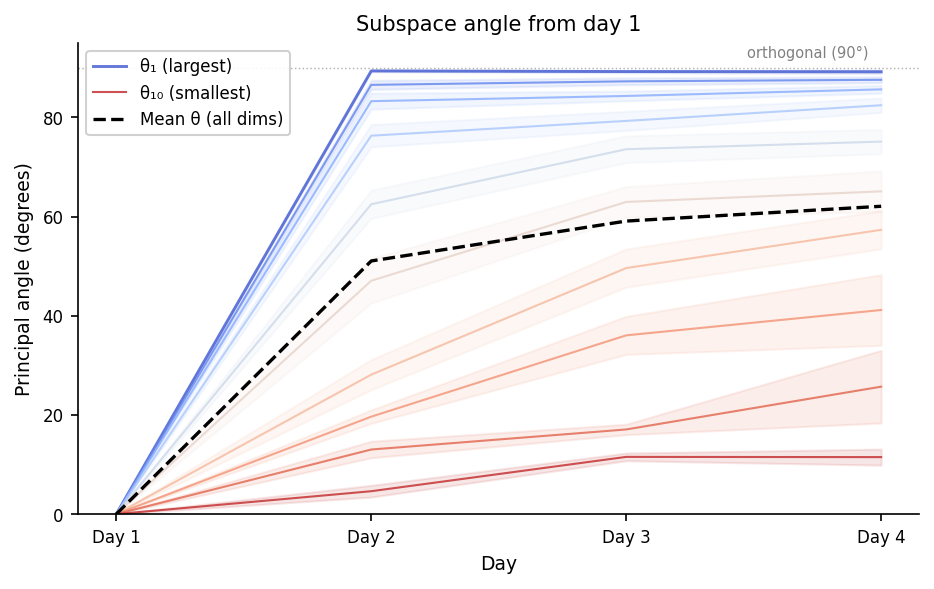

In [4]:
apply_style()
fig, ax = plt.subplots(figsize=FIG_SIZES["single_a4"])

# Colour gradient: blue (large angles / most-rotated) → red (small angles / least-rotated)
palette = cm.coolwarm(np.linspace(0.05, 0.95, k))

for dim in range(k):
    y_mean = np.concatenate([[0.0], mean_angles[:, dim]])
    y_sem  = np.concatenate([[0.0], sem_angles[:, dim]])
    lw     = LW["trace"] * 1.4 if dim == 0 else LW["trace"]
    label  = "θ₁ (largest)" if dim == 0 else ("θ₁₀ (smallest)" if dim == k-1 else None)
    ax.plot(x_days, y_mean, color=palette[dim], lw=lw, label=label, alpha=0.85)
    ax.fill_between(x_days, y_mean - y_sem, y_mean + y_sem,
                    color=palette[dim], alpha=0.12)

# Mean across all k dimensions
mean_over_dims = np.concatenate([[0.0], mean_angles.mean(axis=1)])
ax.plot(x_days, mean_over_dims, color="black", lw=LW["trace"] * 1.6,
        ls="--", label="Mean θ (all dims)", zorder=6)

# Orthogonality reference
ax.axhline(90, color="gray", lw=0.7, ls=":", alpha=0.6)
ax.text(x_days[-1] - 0.05, 91.5, "orthogonal (90°)",
        fontsize=FONT["annotation"] - 1, color="gray", ha="right", va="bottom")

ax.set_xticks(x_days)
ax.set_xticklabels([f"Day {d}" for d in x_days])
ax.set_xlabel("Day")
ax.set_ylabel("Principal angle (degrees)")
ax.set_title("Subspace angle from day 1")
ax.set_ylim(0, 95)
ax.legend(fontsize=FONT["annotation"], loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

In [5]:
out_path = os.path.join(FIGURES_DIR, "fig2_1_1_subspace_angle.pdf")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Figure saved -> {out_path}")


Figure saved -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\saved_figures\fig2_1_1_subspace_angle.pdf
